In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
#Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [3]:
#Change date format
df["Order_Date"] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

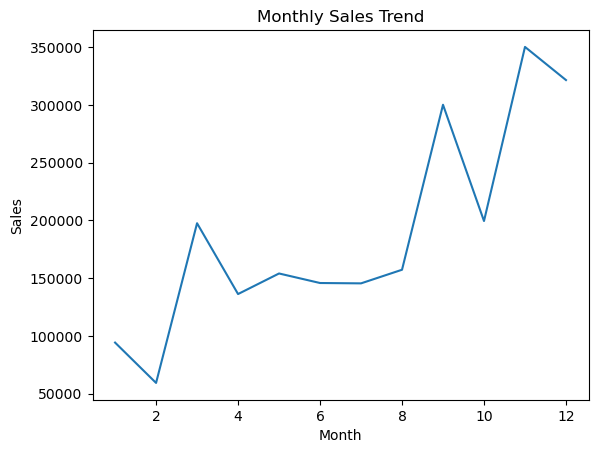

In [4]:
#Monthly sales analysis
monthly_sales = df.groupby(df['Order_Date'].dt.month)['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

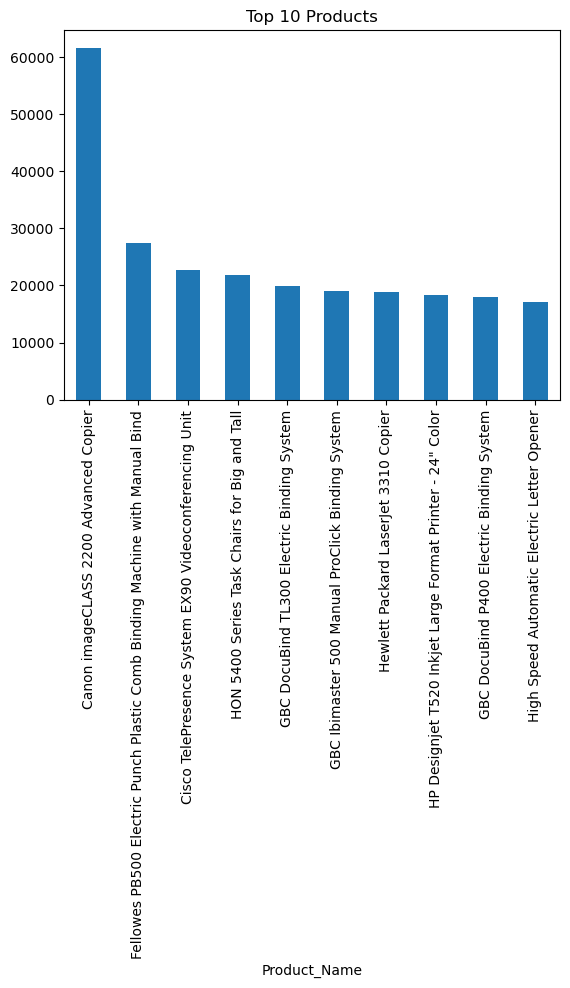

In [5]:
#Classify Top products
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

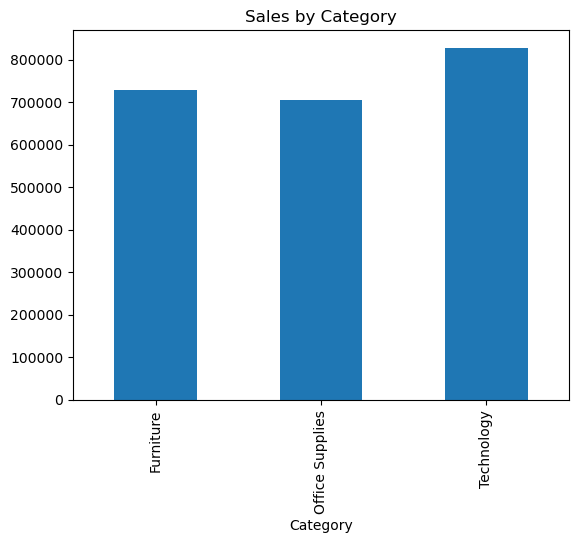

In [6]:
#Classify sales by category
category_sales = df.groupby("Category")['Sales'].sum()

category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

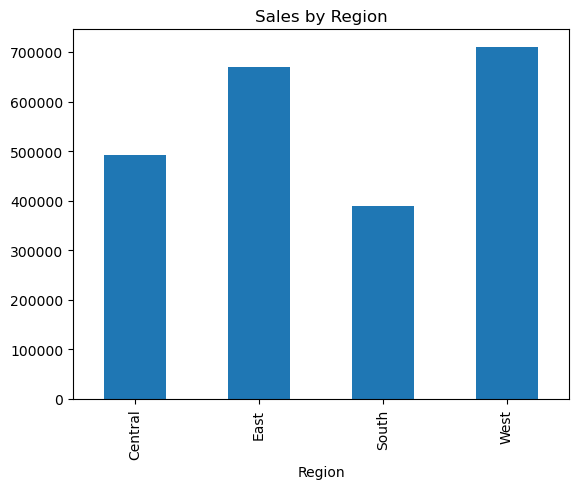

In [7]:
#Classify sales by Region
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

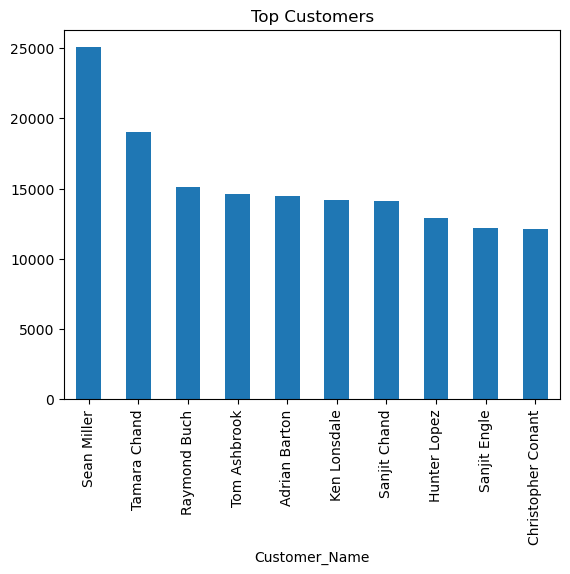

In [8]:
#Identify top customers
top_customers = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top Customers")
plt.show()

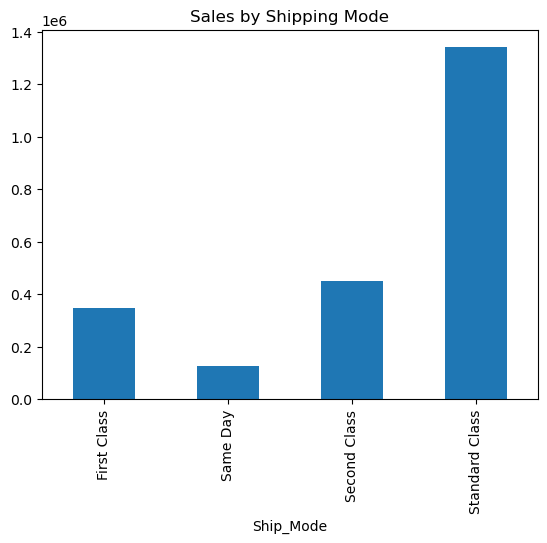

In [9]:
#Shipping analysis
ship_mode_sales = df.groupby('Ship_Mode')['Sales'].sum()

ship_mode_sales.plot(kind='bar')
plt.title("Sales by Shipping Mode")
plt.show()

In [10]:
#Key insights

#Sales increase towaards the end of the year
#The most profitable and performing category is Technology
#Standard class shipping method is most preferred